In [13]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv("E-commerce_Delivery_Shipping_Data_2026.csv")

# Basic inspection
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

print("\nDataset Information:")
df.info()

Dataset Shape: (50000, 30)

Column Names:
['order_id', 'order_date', 'customer_id', 'customer_segment', 'customer_city', 'customer_country', 'warehouse_id', 'warehouse_city', 'product_category', 'product_weight_kg', 'order_value_usd', 'shipping_method', 'carrier', 'distance_km', 'promised_delivery_days', 'actual_delivery_days', 'delivery_status', 'late_delivery', 'delivery_delay_days', 'shipping_cost_usd', 'package_size', 'payment_method', 'order_priority', 'weather_condition', 'customer_rating', 'return_requested', 'return_reason', 'delivery_attempts', 'warehouse_processing_hours', 'tracking_status']

First 5 Rows:


,order_id,order_date,customer_id,customer_segment,customer_city,customer_country,warehouse_id,warehouse_city,product_category,product_weight_kg,order_value_usd,shipping_method,carrier,distance_km,promised_delivery_days,actual_delivery_days,delivery_status,late_delivery,delivery_delay_days,shipping_cost_usd,package_size,payment_method,order_priority,weather_condition,customer_rating,return_requested,return_reason,delivery_attempts,warehouse_processing_hours,tracking_status
0,ORD-000001,2026-11-15,CUS-002353,Small Business,Tokyo,Japan,WH-004,Toronto,Home & Kitchen,8.23,10.39,International,EagleCourier,1579.5,11,16,Delivered,Yes,5,133.10,Large,Digital Wallet,Normal,Snow,3,Yes,Late Delivery,2,25.1,Delivered
1,ORD-000002,2026-04-08,CUS-003258,Consumer,Vancouver,Canada,WH-007,Paris,Beauty,0.10,117.69,Standard,BlueRoute,1049.0,5,5,Delivered,No,0,26.95,Small,Debit Card,Normal,Cloudy,5,No,NaN,1,25.9,Delivered
2,ORD-000003,2026-01-05,CUS-001221,Consumer,Houston,United States,WH-005,London,Home & Kitchen,5.51,335.23,International,SpeedyCargo,4552.6,12,16,Delivered,Yes,4,338.62,Large,Debit Card,Low,Snow,4,Yes,Product Defect,1,31.5,Delivered
3,ORD-000004,2026-05-29,CUS-001717,Small Business,Delhi,India,WH-002,Los Angeles,Grocery,3.75,10.57,Standard,ParcelPro,7074.9,8,11,In Transit,Yes,3,270.45,Large,Debit Card,Normal,Snow,3,No,NaN,1,12.6,In Transit
4,ORD-000005,2026-02-22,CUS-000716,Small Business,Nagoya,Japan,WH-006,Berlin,Beauty,0.10,31.37,Economy,GlobalExpress,522.0,8,12,Delivered,Yes,4,12.90,Small,Credit Card,Normal,Storm,2,No,NaN,1,24.9,Delivered



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   order_id                    50000 non-null  object 
 1   order_date                  50000 non-null  object 
 2   customer_id                 50000 non-null  object 
 3   customer_segment            50000 non-null  object 
 4   customer_city               50000 non-null  object 
 5   customer_country            50000 non-null  object 
 6   warehouse_id                50000 non-null  object 
 7   warehouse_city              50000 non-null  object 
 8   product_category            50000 non-null  object 
 9   product_weight_kg           50000 non-null  float64
 10  order_value_usd             50000 non-null  float64
 11  shipping_method             50000 non-null  object 
 12  carrier                     50000 non-null  object 
 13  distance_

In [15]:
# ==========================================
# STEP 2.2 - DATA QUALITY CHECKS
# ==========================================

# 1. Check missing values
missing_values = df.isnull().sum()

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Values': missing_values,
    'Missing Percentage': missing_percentage
})

# Show only columns with missing values
missing_summary[missing_summary['Missing Values'] > 0]

,Missing Values,Missing Percentage
return_reason,41375,82.75


In [17]:
# Check for completely duplicated rows
duplicate_rows = df.duplicated().sum()

print("Duplicate rows:", duplicate_rows)

Duplicate rows: 0


In [19]:
# Check duplicate order IDs
duplicate_orders = df['order_id'].duplicated().sum()

print("Duplicate Order IDs:", duplicate_orders)

Duplicate Order IDs: 0


In [21]:
# Important categorical columns
categorical_columns = [
    'customer_segment',
    'product_category',
    'shipping_method',
    'carrier',
    'delivery_status',
    'late_delivery',
    'package_size',
    'payment_method',
    'order_priority',
    'weather_condition',
    'return_requested',
    'return_reason',
    'tracking_status'
]

for column in categorical_columns:
    print(f"\n{'='*50}")
    print(column)
    print(f"{'='*50}")
    print(df[column].value_counts(dropna=False))


customer_segment
customer_segment
Consumer          30167
Small Business     9947
Enterprise         6027
Premium            3859
Name: count, dtype: int64

product_category
product_category
Electronics               7406
Fashion                   7158
Home & Kitchen            5902
Grocery                   4054
Beauty                    3976
Books                     3598
Sports & Fitness          3466
Health & Personal Care    3061
Toys                      3050
Office Supplies           2953
Automotive                2908
Pet Supplies              2468
Name: count, dtype: int64

shipping_method
shipping_method
Standard         17027
International    15839
Express           9696
Economy           5577
Same Day          1861
Name: count, dtype: int64

carrier
carrier
BlueRoute              6435
ParcelPro              6374
SpeedyCargo            6257
SwiftShip              6233
GlobalExpress          6231
EagleCourier           6213
PrimeDelivery          6185
FastTrack Logistics    

In [23]:
# Convert order_date to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Check the data type
print(df['order_date'].dtype)

datetime64[ns]


In [25]:
print("Minimum Order Date:", df['order_date'].min())
print("Maximum Order Date:", df['order_date'].max())

Minimum Order Date: 2026-01-01 00:00:00
Maximum Order Date: 2026-12-31 00:00:00


In [27]:
# Numerical columns to validate

numeric_columns = [
    'product_weight_kg',
    'order_value_usd',
    'distance_km',
    'promised_delivery_days',
    'actual_delivery_days',
    'delivery_delay_days',
    'shipping_cost_usd',
    'customer_rating',
    'delivery_attempts',
    'warehouse_processing_hours'
]

df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
product_weight_kg,50000.0,2.255028,3.694952,0.10,0.320,0.93,2.6100,52.19
order_value_usd,50000.0,177.917107,291.600047,10.00,28.720,76.84,173.1625,3530.73
distance_km,50000.0,2496.778802,1774.633152,40.00,1086.775,2182.80,3592.4750,9553.60
promised_delivery_days,50000.0,7.197700,3.680229,0.00,4.000,6.00,11.0000,15.00
actual_delivery_days,50000.0,8.345940,4.644353,0.00,5.000,8.00,12.0000,27.00
delivery_delay_days,50000.0,1.281080,1.679527,0.00,0.000,1.00,2.0000,13.00
shipping_cost_usd,50000.0,120.515538,108.680030,4.05,40.640,82.97,167.4225,500.00
customer_rating,50000.0,3.371840,0.998777,1.00,3.000,3.00,4.0000,5.00
delivery_attempts,50000.0,1.169860,0.390756,1.00,1.000,1.00,1.0000,3.00
warehouse_processing_hours,50000.0,14.412430,9.924904,1.00,6.600,11.90,20.7000,48.00


In [29]:
# Check customer rating range

print("Minimum Rating:", df['customer_rating'].min())
print("Maximum Rating:", df['customer_rating'].max())

# Check invalid ratings
invalid_ratings = df[
    (df['customer_rating'] < 1) |
    (df['customer_rating'] > 5)
]

print("Invalid Rating Records:", len(invalid_ratings))

Minimum Rating: 1
Maximum Rating: 5
Invalid Rating Records: 0


In [31]:
# Check for negative values

for column in numeric_columns:
    negative_count = (df[column] < 0).sum()
    
    if negative_count > 0:
        print(f"{column}: {negative_count} negative values")
    else:
        print(f"{column}: No negative values")

product_weight_kg: No negative values
order_value_usd: No negative values
distance_km: No negative values
promised_delivery_days: No negative values
actual_delivery_days: No negative values
delivery_delay_days: No negative values
shipping_cost_usd: No negative values
customer_rating: No negative values
delivery_attempts: No negative values
warehouse_processing_hours: No negative values


In [33]:
print(df['delivery_status'].value_counts())

delivery_status
Delivered          44184
In Transit          4007
Delayed             1806
Failed Delivery        3
Name: count, dtype: int64


In [35]:
delivery_status_summary = (
    df['delivery_status']
    .value_counts()
    .to_frame('Orders')
)

delivery_status_summary['Percentage'] = (
    delivery_status_summary['Orders'] / len(df) * 100
).round(2)

delivery_status_summary

,Orders,Percentage
delivery_status,,
Delivered,44184,88.37
In Transit,4007,8.01
Delayed,1806,3.61
Failed Delivery,3,0.01


In [37]:
non_delivered = df[df['delivery_status'] != 'Delivered']

print("Non-delivered orders:", len(non_delivered))
print(
    "Non-delivered orders with ratings:",
    non_delivered['customer_rating'].notna().sum()
)

non_delivered_returns = non_delivered[
    non_delivered['return_requested'] == 'Yes'
]

print(
    "Non-delivered orders with return requests:",
    len(non_delivered_returns)
)

Non-delivered orders: 5816
Non-delivered orders with ratings: 5816
Non-delivered orders with return requests: 1144


In [39]:
# Create a separate dataset for customer experience and return analysis

delivered_df = df[df['delivery_status'] == 'Delivered'].copy()

print("Total orders:", len(df))
print("Delivered orders:", len(delivered_df))
print("Delivered percentage:", round(len(delivered_df) / len(df) * 100, 2), "%")

Total orders: 50000
Delivered orders: 44184
Delivered percentage: 88.37 %


In [41]:
# Create dataset containing only delivered orders
delivered_df = df[df['delivery_status'] == 'Delivered'].copy()

print("Full dataset:", df.shape)
print("Delivered dataset:", delivered_df.shape)

Full dataset: (50000, 30)
Delivered dataset: (44184, 30)


In [43]:
def create_delay_group(delay):
    if delay == 0:
        return 'On Time'
    elif delay <= 2:
        return '1–2 Days Late'
    elif delay <= 5:
        return '3–5 Days Late'
    else:
        return 'More than 5 Days Late'


delivered_df['delay_group'] = delivered_df['delivery_delay_days'].apply(create_delay_group)

df['delay_group'] = df['delivery_delay_days'].apply(create_delay_group)

In [45]:
delivered_df['delay_group'].value_counts()

delivered_df['delay_group'].value_counts(normalize=True).mul(100).round(2)

delay_group
On Time                  45.90
1–2 Days Late            38.70
3–5 Days Late            12.96
More than 5 Days Late     2.44
Name: proportion, dtype: float64

In [47]:
delivered_df[['delivery_delay_days', 'delay_group']].head(10)

,delivery_delay_days,delay_group
0,5,3–5 Days Late
1,0,On Time
2,4,3–5 Days Late
4,4,3–5 Days Late
5,2,1–2 Days Late
6,1,1–2 Days Late
7,5,3–5 Days Late
8,0,On Time
9,1,1–2 Days Late
10,0,On Time


In [49]:
data_quality_summary = pd.DataFrame({
    'Check': [
        'Total rows',
        'Total columns',
        'Duplicate rows',
        'Duplicate order IDs',
        'Missing return reasons',
        'Delivered orders',
        'Non-delivered orders'
    ],
    'Result': [
        len(df),
        len(df.columns),
        df.duplicated().sum(),
        df['order_id'].duplicated().sum(),
        df['return_reason'].isna().sum(),
        (df['delivery_status'] == 'Delivered').sum(),
        (df['delivery_status'] != 'Delivered').sum()
    ]
})

data_quality_summary

,Check,Result
0,Total rows,50000
1,Total columns,31
2,Duplicate rows,0
3,Duplicate order IDs,0
4,Missing return reasons,41375
5,Delivered orders,44184
6,Non-delivered orders,5816


In [51]:
df.to_csv(
    'ecommerce_delivery_cleaned_full.csv',
    index=False
)

In [53]:
delivered_df.to_csv(
    'ecommerce_customer_experience_delivered.csv',
    index=False
)

In [55]:
import os

print("Full dataset exists:",
      os.path.exists('ecommerce_delivery_cleaned_full.csv'))

print("Delivered dataset exists:",
      os.path.exists('ecommerce_customer_experience_delivered.csv'))

Full dataset exists: True
Delivered dataset exists: True


In [57]:
print("FULL DATASET")
print(df.shape)

print("\nDELIVERED DATASET")
print(delivered_df.shape)

print("\nDATE RANGE")
print(df['order_date'].min(), "to", df['order_date'].max())

print("\nDELIVERY STATUS")
print(df['delivery_status'].value_counts())

print("\nDELAY GROUPS - DELIVERED ORDERS")
print(delivered_df['delay_group'].value_counts())

FULL DATASET
(50000, 31)

DELIVERED DATASET
(44184, 31)

DATE RANGE
2026-01-01 00:00:00 to 2026-12-31 00:00:00

DELIVERY STATUS
delivery_status
Delivered          44184
In Transit          4007
Delayed             1806
Failed Delivery        3
Name: count, dtype: int64

DELAY GROUPS - DELIVERED ORDERS
delay_group
On Time                  20282
1–2 Days Late            17097
3–5 Days Late             5726
More than 5 Days Late     1079
Name: count, dtype: int64


In [59]:
# ==========================================
# STEP 3.1 - DELIVERY KPIs
# ==========================================

total_orders = len(df)

late_orders = (df['late_delivery'] == 'Yes').sum()

late_delivery_rate = (late_orders / total_orders) * 100

average_delivery_delay = df['delivery_delay_days'].mean()

average_delivery_time = df['actual_delivery_days'].mean()

average_delivery_attempts = df['delivery_attempts'].mean()

print("Total Orders:", total_orders)
print("Late Orders:", late_orders)
print("Late Delivery Rate:", round(late_delivery_rate, 2), "%")
print("Average Delivery Delay:", round(average_delivery_delay, 2), "days")
print("Average Delivery Time:", round(average_delivery_time, 2), "days")
print("Average Delivery Attempts:", round(average_delivery_attempts, 2))

Total Orders: 50000
Late Orders: 28162
Late Delivery Rate: 56.32 %
Average Delivery Delay: 1.28 days
Average Delivery Time: 8.35 days
Average Delivery Attempts: 1.17


In [61]:
# ==========================================
# STEP 3.2 - CUSTOMER EXPERIENCE KPIs
# ==========================================

average_rating = delivered_df['customer_rating'].mean()

low_rating_orders = (delivered_df['customer_rating'] <= 2).sum()

high_rating_orders = (delivered_df['customer_rating'] >= 4).sum()

print("Average Customer Rating:", round(average_rating, 2))
print("Low Rating Orders (1-2):", low_rating_orders)
print("High Rating Orders (4-5):", high_rating_orders)

Average Customer Rating: 3.43
Low Rating Orders (1-2): 8602
High Rating Orders (4-5): 22020


In [63]:
rating_distribution = (
    delivered_df['customer_rating']
    .value_counts()
    .sort_index()
)

rating_distribution

rating_percentage = (
    delivered_df['customer_rating']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

rating_summary = pd.DataFrame({
    'Orders': rating_distribution,
    'Percentage': rating_percentage
})

rating_summary

,Orders,Percentage
customer_rating,,
1,631,1.43
2,7971,18.04
3,13562,30.69
4,15639,35.40
5,6381,14.44


In [65]:
# ==========================================
# STEP 3.4 - RETURN KPIs
# ==========================================

total_returns = (
    delivered_df['return_requested'] == 'Yes'
).sum()

total_delivered_orders = len(delivered_df)

return_rate = (
    total_returns / total_delivered_orders
) * 100

returned_order_value = delivered_df.loc[
    delivered_df['return_requested'] == 'Yes',
    'order_value_usd'
].sum()

print("Delivered Orders:", total_delivered_orders)
print("Total Returns:", total_returns)
print("Return Rate:", round(return_rate, 2), "%")
print("Returned Order Value: $", round(returned_order_value, 2))

Delivered Orders: 44184
Total Returns: 7481
Return Rate: 16.93 %
Returned Order Value: $ 1359531.32


In [67]:
average_order_value = delivered_df['order_value_usd'].mean()

print(
    "Average Order Value: $",
    round(average_order_value, 2)
)

Average Order Value: $ 177.19


In [69]:
kpi_summary = pd.DataFrame({
    'KPI': [
        'Total Orders',
        'Delivered Orders',
        'Late Orders',
        'Late Delivery Rate',
        'Average Delivery Delay (Days)',
        'Average Delivery Time (Days)',
        'Average Delivery Attempts',
        'Average Customer Rating',
        'Low Rating Orders (1-2)',
        'High Rating Orders (4-5)',
        'Total Returns',
        'Return Rate',
        'Returned Order Value (USD)',
        'Average Order Value (USD)'
    ],
    
    'Value': [
        total_orders,
        total_delivered_orders,
        late_orders,
        round(late_delivery_rate, 2),
        round(average_delivery_delay, 2),
        round(average_delivery_time, 2),
        round(average_delivery_attempts, 2),
        round(average_rating, 2),
        low_rating_orders,
        high_rating_orders,
        total_returns,
        round(return_rate, 2),
        round(returned_order_value, 2),
        round(average_order_value, 2)
    ]
})

kpi_summary

,KPI,Value
0,Total Orders,50000.00
1,Delivered Orders,44184.00
2,Late Orders,28162.00
3,Late Delivery Rate,56.32
4,Average Delivery Delay (Days),1.28
5,Average Delivery Time (Days),8.35
6,Average Delivery Attempts,1.17
7,Average Customer Rating,3.43
8,Low Rating Orders (1-2),8602.00
9,High Rating Orders (4-5),22020.00


In [71]:
# ==========================================
# STEP 4.1 - DELIVERY DELAY VS CUSTOMER RATING
# ==========================================

rating_by_delay = (
    delivered_df
    .groupby('delay_group')['customer_rating']
    .agg(['count', 'mean'])
    .reset_index()
)

rating_by_delay.columns = [
    'Delay Group',
    'Orders',
    'Average Rating'
]

rating_by_delay['Average Rating'] = (
    rating_by_delay['Average Rating'].round(2)
)

rating_by_delay

,Delay Group,Orders,Average Rating
0,1–2 Days Late,17097,2.75
1,3–5 Days Late,5726,2.76
2,More than 5 Days Late,1079,2.78
3,On Time,20282,4.23


In [73]:
delay_order = [
    'On Time',
    '1–2 Days Late',
    '3–5 Days Late',
    'More than 5 Days Late'
]

rating_by_delay['Delay Group'] = pd.Categorical(
    rating_by_delay['Delay Group'],
    categories=delay_order,
    ordered=True
)

rating_by_delay = rating_by_delay.sort_values('Delay Group')

rating_by_delay

,Delay Group,Orders,Average Rating
3,On Time,20282,4.23
0,1–2 Days Late,17097,2.75
1,3–5 Days Late,5726,2.76
2,More than 5 Days Late,1079,2.78


In [75]:
on_time_rating = rating_by_delay.loc[
    rating_by_delay['Delay Group'] == 'On Time',
    'Average Rating'
].iloc[0]

very_late_rating = rating_by_delay.loc[
    rating_by_delay['Delay Group'] == 'More than 5 Days Late',
    'Average Rating'
].iloc[0]

rating_difference = on_time_rating - very_late_rating

print("On-time average rating:", on_time_rating)
print("More than 5 days late rating:", very_late_rating)
print("Difference:", round(rating_difference, 2))

On-time average rating: 4.23
More than 5 days late rating: 2.78
Difference: 1.45


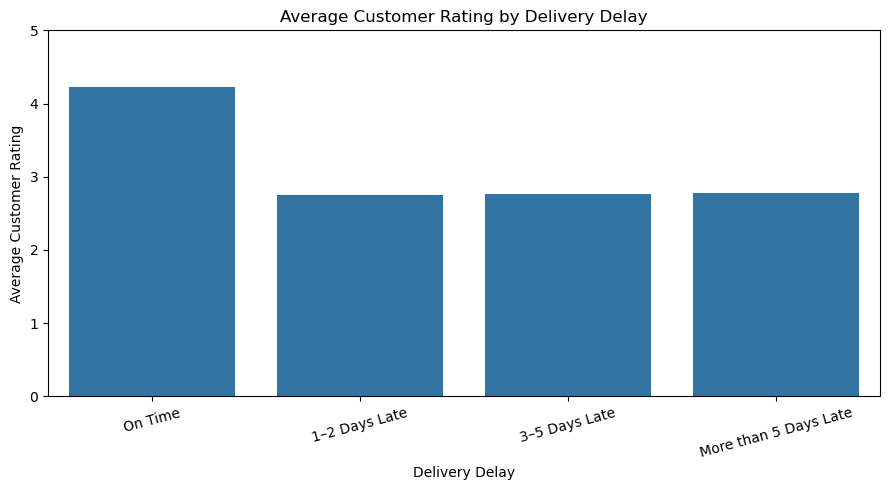

In [77]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=rating_by_delay,
    x='Delay Group',
    y='Average Rating'
)

plt.title('Average Customer Rating by Delivery Delay')
plt.xlabel('Delivery Delay')
plt.ylabel('Average Customer Rating')

plt.ylim(0, 5)

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [79]:
rating_by_delay

,Delay Group,Orders,Average Rating
3,On Time,20282,4.23
0,1–2 Days Late,17097,2.75
1,3–5 Days Late,5726,2.76
2,More than 5 Days Late,1079,2.78


In [81]:
# ==========================================
# STEP 4.2 - DELIVERY ATTEMPTS VS RATING
# ==========================================

rating_by_attempts = (
    delivered_df
    .groupby('delivery_attempts')['customer_rating']
    .agg(['count', 'mean'])
    .reset_index()
)

rating_by_attempts.columns = [
    'Delivery Attempts',
    'Orders',
    'Average Rating'
]

rating_by_attempts['Average Rating'] = (
    rating_by_attempts['Average Rating'].round(2)
)

rating_by_attempts

,Delivery Attempts,Orders,Average Rating
0,1,37498,3.43
1,2,6686,3.44


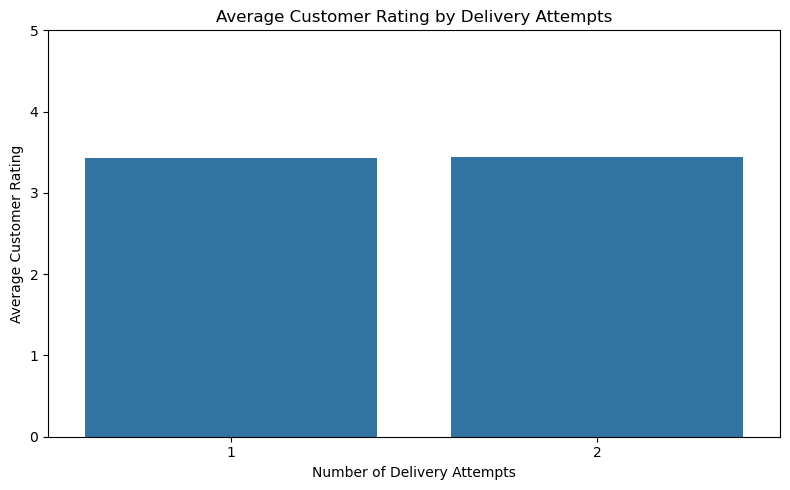

In [83]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=rating_by_attempts,
    x='Delivery Attempts',
    y='Average Rating'
)

plt.title('Average Customer Rating by Delivery Attempts')
plt.xlabel('Number of Delivery Attempts')
plt.ylabel('Average Customer Rating')

plt.ylim(0, 5)

plt.tight_layout()
plt.show()

In [85]:
rating_by_attempts

,Delivery Attempts,Orders,Average Rating
0,1,37498,3.43
1,2,6686,3.44


In [87]:
# ==========================================
# STEP 4.3 - SHIPPING METHOD VS RATING
# ==========================================

rating_by_shipping = (
    delivered_df
    .groupby('shipping_method')['customer_rating']
    .agg(['count', 'mean'])
    .reset_index()
)

rating_by_shipping.columns = [
    'Shipping Method',
    'Orders',
    'Average Rating'
]

rating_by_shipping['Average Rating'] = (
    rating_by_shipping['Average Rating'].round(2)
)

rating_by_shipping = rating_by_shipping.sort_values(
    'Average Rating',
    ascending=False
)

rating_by_shipping

,Shipping Method,Orders,Average Rating
3,Same Day,1650,3.93
1,Express,8461,3.65
4,Standard,15135,3.45
0,Economy,4937,3.34
2,International,14001,3.26


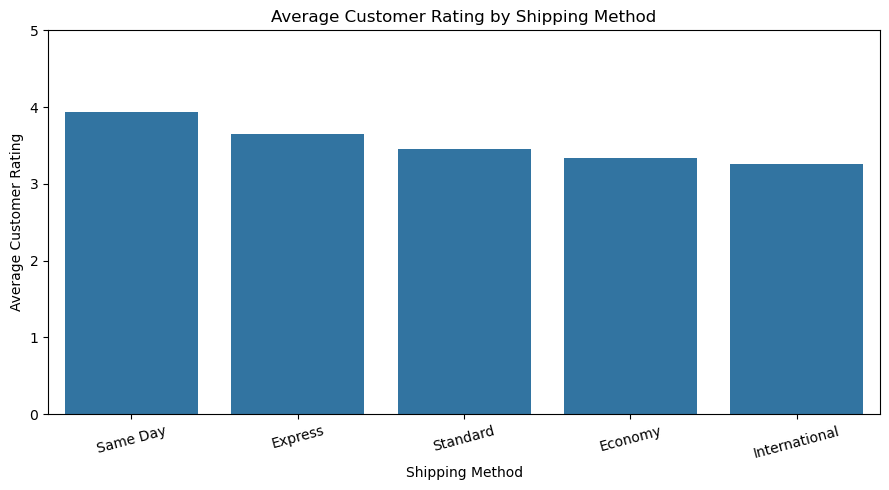

In [89]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=rating_by_shipping,
    x='Shipping Method',
    y='Average Rating'
)

plt.title('Average Customer Rating by Shipping Method')
plt.xlabel('Shipping Method')
plt.ylabel('Average Customer Rating')

plt.ylim(0, 5)

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [91]:
rating_by_shipping

,Shipping Method,Orders,Average Rating
3,Same Day,1650,3.93
1,Express,8461,3.65
4,Standard,15135,3.45
0,Economy,4937,3.34
2,International,14001,3.26


In [93]:
# ==========================================
# STEP 4.4 - CUSTOMER SEGMENT VS RATING
# ==========================================

rating_by_segment = (
    delivered_df
    .groupby('customer_segment')['customer_rating']
    .agg(['count', 'mean'])
    .reset_index()
)

rating_by_segment.columns = [
    'Customer Segment',
    'Orders',
    'Average Rating'
]

rating_by_segment['Average Rating'] = (
    rating_by_segment['Average Rating'].round(2)
)

rating_by_segment = rating_by_segment.sort_values(
    'Average Rating',
    ascending=False
)

rating_by_segment

,Customer Segment,Orders,Average Rating
3,Small Business,8774,3.46
0,Consumer,26620,3.43
2,Premium,3450,3.43
1,Enterprise,5340,3.42


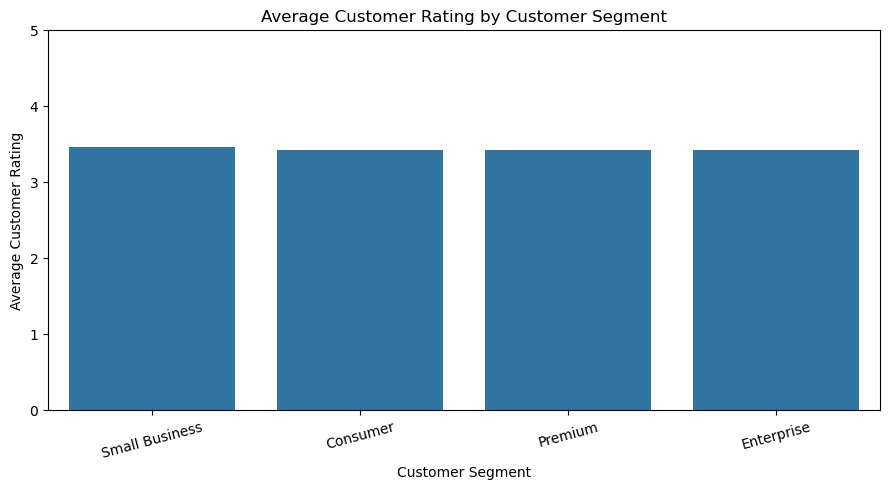

In [95]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=rating_by_segment,
    x='Customer Segment',
    y='Average Rating'
)

plt.title('Average Customer Rating by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Customer Rating')

plt.ylim(0, 5)

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [97]:
rating_by_segment

,Customer Segment,Orders,Average Rating
3,Small Business,8774,3.46
0,Consumer,26620,3.43
2,Premium,3450,3.43
1,Enterprise,5340,3.42


In [99]:
# ==========================================
# STEP 4.5 - PRODUCT CATEGORY VS RATING
# ==========================================

rating_by_category = (
    delivered_df
    .groupby('product_category')['customer_rating']
    .agg(['count', 'mean'])
    .reset_index()
)

rating_by_category.columns = [
    'Product Category',
    'Orders',
    'Average Rating'
]

rating_by_category['Average Rating'] = (
    rating_by_category['Average Rating'].round(2)
)

rating_by_category = rating_by_category.sort_values(
    'Average Rating',
    ascending=False
)

rating_by_category

,Product Category,Orders,Average Rating
2,Books,3152,3.45
8,Office Supplies,2627,3.45
4,Fashion,6307,3.44
9,Pet Supplies,2185,3.44
10,Sports & Fitness,3072,3.44
0,Automotive,2554,3.43
1,Beauty,3539,3.43
3,Electronics,6564,3.43
5,Grocery,3594,3.43
11,Toys,2693,3.43


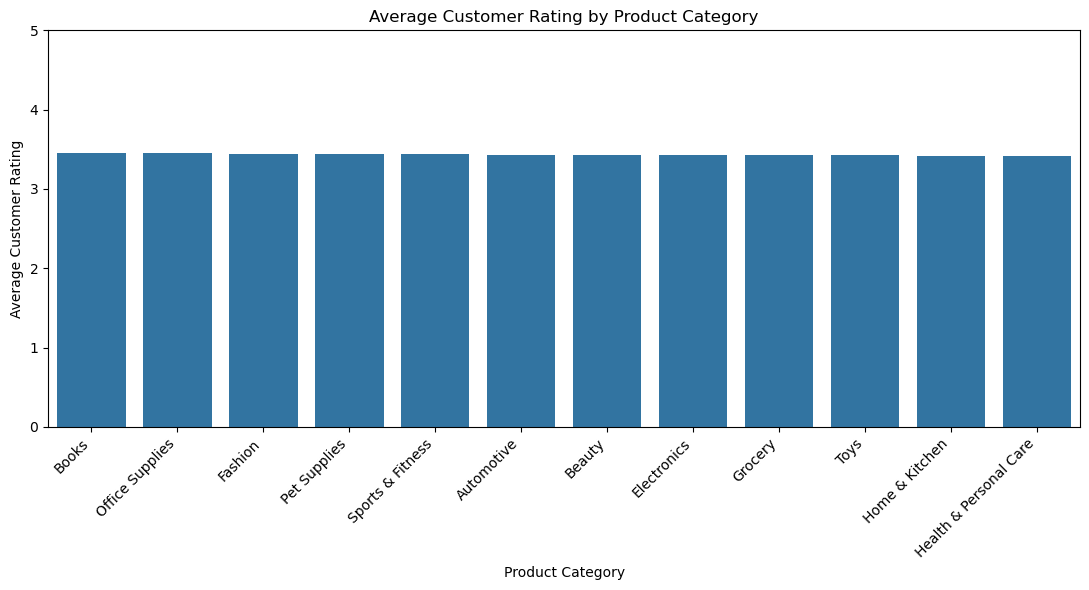

In [101]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=rating_by_category,
    x='Product Category',
    y='Average Rating'
)

plt.title('Average Customer Rating by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Average Customer Rating')

plt.ylim(0, 5)

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [103]:
rating_by_category

,Product Category,Orders,Average Rating
2,Books,3152,3.45
8,Office Supplies,2627,3.45
4,Fashion,6307,3.44
9,Pet Supplies,2185,3.44
10,Sports & Fitness,3072,3.44
0,Automotive,2554,3.43
1,Beauty,3539,3.43
3,Electronics,6564,3.43
5,Grocery,3594,3.43
11,Toys,2693,3.43


In [105]:
# ==========================================
# STEP 5.1 - RETURN RATE BY PRODUCT CATEGORY
# ==========================================

return_by_category = (
    delivered_df
    .groupby('product_category')
    .agg(
        Orders=('order_id', 'count'),
        Returned_Orders=(
            'return_requested',
            lambda x: (x == 'Yes').sum()
        )
    )
    .reset_index()
)

return_by_category['Return Rate'] = (
    return_by_category['Returned_Orders']
    / return_by_category['Orders']
    * 100
).round(2)

return_by_category = return_by_category.sort_values(
    'Return Rate',
    ascending=False
)

return_by_category

,product_category,Orders,Returned_Orders,Return Rate
4,Fashion,6307,1152,18.27
3,Electronics,6564,1184,18.04
9,Pet Supplies,2185,386,17.67
8,Office Supplies,2627,451,17.17
0,Automotive,2554,435,17.03
6,Health & Personal Care,2735,462,16.89
5,Grocery,3594,590,16.42
7,Home & Kitchen,5162,842,16.31
1,Beauty,3539,573,16.19
10,Sports & Fitness,3072,494,16.08


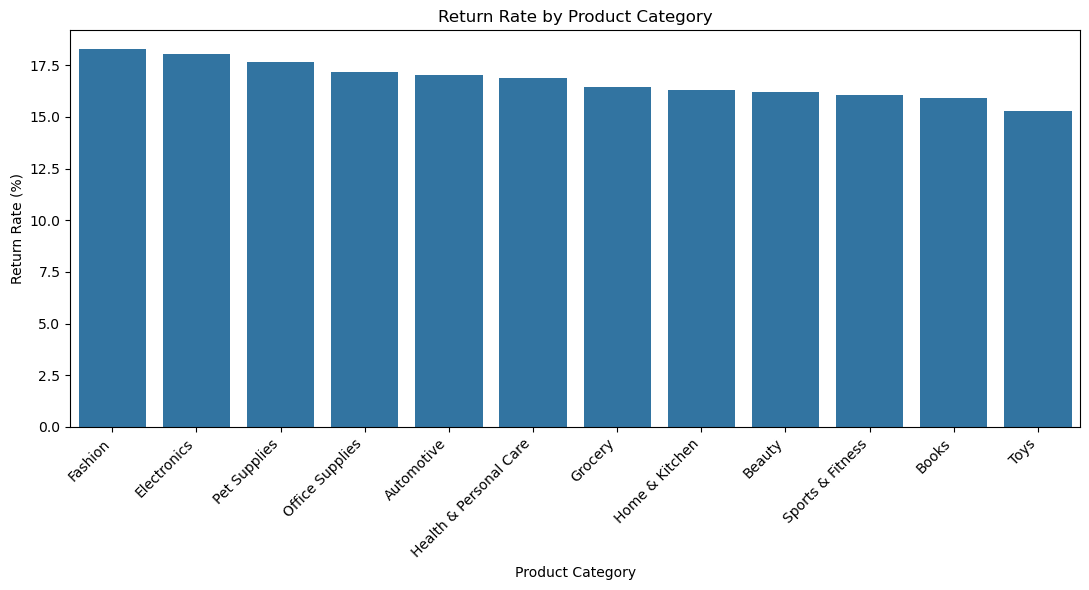

In [107]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=return_by_category,
    x='product_category',
    y='Return Rate'
)

plt.title('Return Rate by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Return Rate (%)')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [109]:
return_by_category

,product_category,Orders,Returned_Orders,Return Rate
4,Fashion,6307,1152,18.27
3,Electronics,6564,1184,18.04
9,Pet Supplies,2185,386,17.67
8,Office Supplies,2627,451,17.17
0,Automotive,2554,435,17.03
6,Health & Personal Care,2735,462,16.89
5,Grocery,3594,590,16.42
7,Home & Kitchen,5162,842,16.31
1,Beauty,3539,573,16.19
10,Sports & Fitness,3072,494,16.08


In [111]:
# ==========================================
# STEP 5.2 - RETURN RATE BY CUSTOMER SEGMENT
# ==========================================

return_by_segment = (
    delivered_df
    .groupby('customer_segment')
    .agg(
        Orders=('order_id', 'count'),
        Returned_Orders=(
            'return_requested',
            lambda x: (x == 'Yes').sum()
        )
    )
    .reset_index()
)

return_by_segment['Return Rate'] = (
    return_by_segment['Returned_Orders']
    / return_by_segment['Orders']
    * 100
).round(2)

return_by_segment = return_by_segment.sort_values(
    'Return Rate',
    ascending=False
)

return_by_segment

,customer_segment,Orders,Returned_Orders,Return Rate
2,Premium,3450,720,20.87
3,Small Business,8774,1475,16.81
0,Consumer,26620,4426,16.63
1,Enterprise,5340,860,16.10


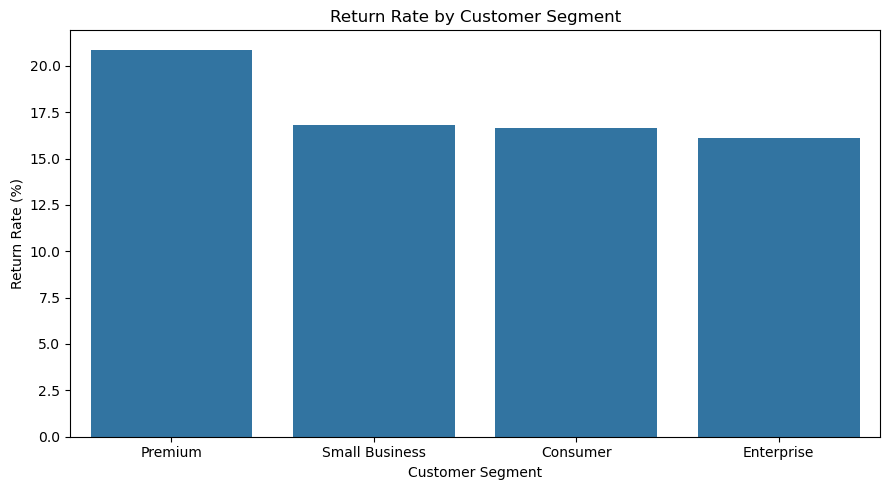

In [113]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=return_by_segment,
    x='customer_segment',
    y='Return Rate'
)

plt.title('Return Rate by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Return Rate (%)')

plt.tight_layout()
plt.show()

In [115]:
return_by_segment

,customer_segment,Orders,Returned_Orders,Return Rate
2,Premium,3450,720,20.87
3,Small Business,8774,1475,16.81
0,Consumer,26620,4426,16.63
1,Enterprise,5340,860,16.10


In [117]:
# ==========================================
# STEP 5.3 - RETURN RATE BY SHIPPING METHOD
# ==========================================

return_by_shipping = (
    delivered_df
    .groupby('shipping_method')
    .agg(
        Orders=('order_id', 'count'),
        Returned_Orders=(
            'return_requested',
            lambda x: (x == 'Yes').sum()
        )
    )
    .reset_index()
)

return_by_shipping['Return Rate'] = (
    return_by_shipping['Returned_Orders']
    / return_by_shipping['Orders']
    * 100
).round(2)

return_by_shipping = return_by_shipping.sort_values(
    'Return Rate',
    ascending=False
)

return_by_shipping

,shipping_method,Orders,Returned_Orders,Return Rate
2,International,14001,2567,18.33
0,Economy,4937,879,17.80
4,Standard,15135,2563,16.93
1,Express,8461,1251,14.79
3,Same Day,1650,221,13.39


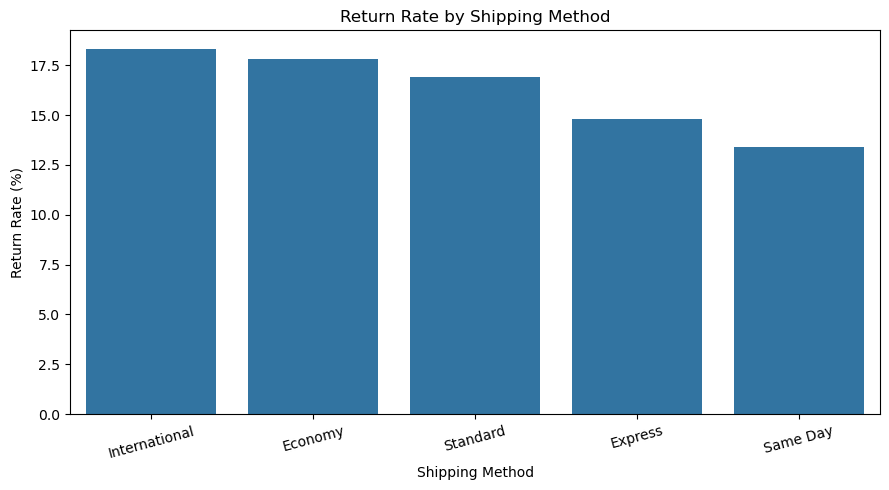

In [119]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=return_by_shipping,
    x='shipping_method',
    y='Return Rate'
)

plt.title('Return Rate by Shipping Method')
plt.xlabel('Shipping Method')
plt.ylabel('Return Rate (%)')

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [121]:
return_by_shipping

,shipping_method,Orders,Returned_Orders,Return Rate
2,International,14001,2567,18.33
0,Economy,4937,879,17.80
4,Standard,15135,2563,16.93
1,Express,8461,1251,14.79
3,Same Day,1650,221,13.39


In [123]:
# ==========================================
# STEP 5.4 - RETURN RATE BY DELIVERY DELAY
# ==========================================

return_by_delay = (
    delivered_df
    .groupby('delay_group')
    .agg(
        Orders=('order_id', 'count'),
        Returned_Orders=(
            'return_requested',
            lambda x: (x == 'Yes').sum()
        )
    )
    .reset_index()
)

return_by_delay['Return Rate'] = (
    return_by_delay['Returned_Orders']
    / return_by_delay['Orders']
    * 100
).round(2)

# Put delay groups in logical order
delay_order = [
    'On Time',
    '1–2 Days Late',
    '3–5 Days Late',
    'More than 5 Days Late'
]

return_by_delay['delay_group'] = pd.Categorical(
    return_by_delay['delay_group'],
    categories=delay_order,
    ordered=True
)

return_by_delay = return_by_delay.sort_values('delay_group')

return_by_delay

,delay_group,Orders,Returned_Orders,Return Rate
3,On Time,20282,1909,9.41
0,1–2 Days Late,17097,3983,23.30
1,3–5 Days Late,5726,1332,23.26
2,More than 5 Days Late,1079,257,23.82


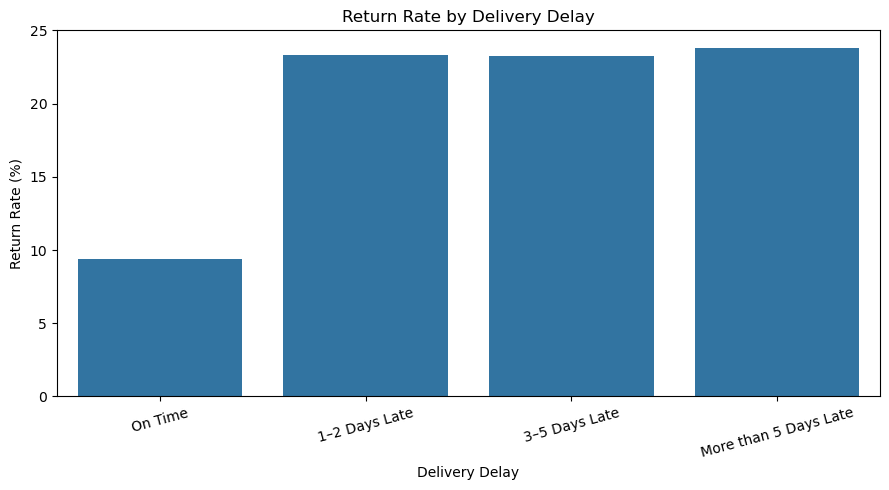

In [125]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=return_by_delay,
    x='delay_group',
    y='Return Rate'
)

plt.title('Return Rate by Delivery Delay')
plt.xlabel('Delivery Delay')
plt.ylabel('Return Rate (%)')

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [127]:
return_by_delay

,delay_group,Orders,Returned_Orders,Return Rate
3,On Time,20282,1909,9.41
0,1–2 Days Late,17097,3983,23.30
1,3–5 Days Late,5726,1332,23.26
2,More than 5 Days Late,1079,257,23.82


In [129]:
# ==========================================
# STEP 5.5 - RETURN REASONS
# ==========================================

return_reasons = (
    delivered_df[
        delivered_df['return_requested'] == 'Yes'
    ]['return_reason']
    .value_counts()
    .reset_index()
)

return_reasons.columns = [
    'Return Reason',
    'Returned Orders'
]

return_reasons

,Return Reason,Returned Orders
0,Product Defect,1890
1,Damaged Package,1308
2,Not as Described,1138
3,Wrong Item,1106
4,Changed Mind,1095
5,Late Delivery,944


In [131]:
return_reasons['Percentage'] = (
    return_reasons['Returned Orders']
    / return_reasons['Returned Orders'].sum()
    * 100
).round(2)

return_reasons

,Return Reason,Returned Orders,Percentage
0,Product Defect,1890,25.26
1,Damaged Package,1308,17.48
2,Not as Described,1138,15.21
3,Wrong Item,1106,14.78
4,Changed Mind,1095,14.64
5,Late Delivery,944,12.62


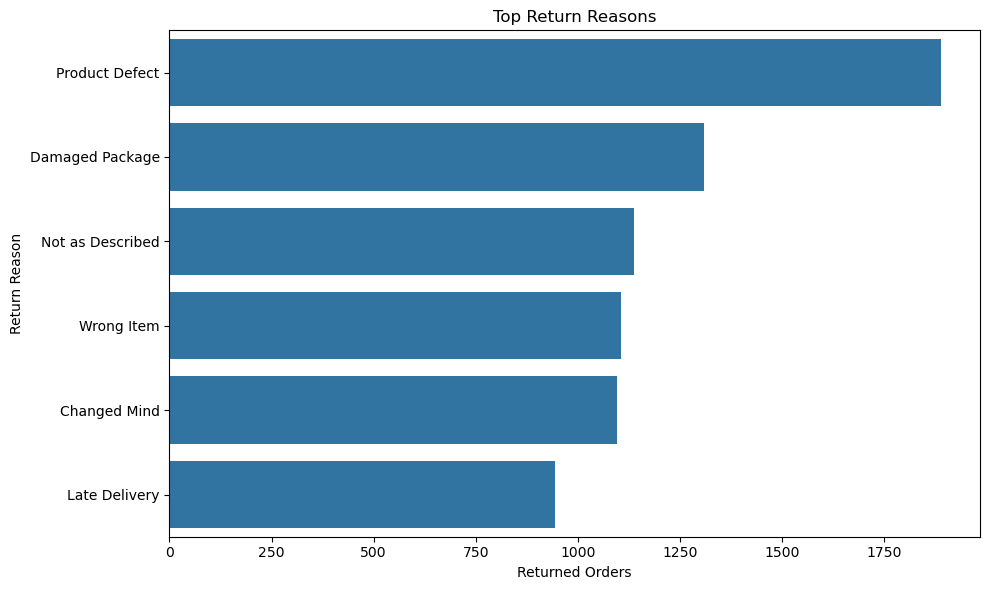

In [133]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=return_reasons,
    x='Returned Orders',
    y='Return Reason'
)

plt.title('Top Return Reasons')
plt.xlabel('Returned Orders')
plt.ylabel('Return Reason')

plt.tight_layout()
plt.show()

In [135]:
# ==========================================
# STEP 5.6 - RETURN REASON BY PRODUCT CATEGORY
# ==========================================

return_reason_category = (
    delivered_df[
        delivered_df['return_requested'] == 'Yes'
    ]
    .groupby(['product_category', 'return_reason'])
    .size()
    .reset_index(name='Returned Orders')
)

return_reason_category

,product_category,return_reason,Returned Orders
0,Automotive,Changed Mind,58
1,Automotive,Damaged Package,71
2,Automotive,Late Delivery,57
3,Automotive,Not as Described,72
4,Automotive,Product Defect,109
5,Automotive,Wrong Item,68
6,Beauty,Changed Mind,77
7,Beauty,Damaged Package,91
8,Beauty,Late Delivery,70
9,Beauty,Not as Described,105


In [137]:
return_reason_category['Percentage'] = (
    return_reason_category
    .groupby('product_category')['Returned Orders']
    .transform(lambda x: x / x.sum() * 100)
    .round(2)
)

return_reason_category

,product_category,return_reason,Returned Orders,Percentage
0,Automotive,Changed Mind,58,13.33
1,Automotive,Damaged Package,71,16.32
2,Automotive,Late Delivery,57,13.10
3,Automotive,Not as Described,72,16.55
4,Automotive,Product Defect,109,25.06
5,Automotive,Wrong Item,68,15.63
6,Beauty,Changed Mind,77,13.44
7,Beauty,Damaged Package,91,15.88
8,Beauty,Late Delivery,70,12.22
9,Beauty,Not as Described,105,18.32


In [139]:
return_reason_category = return_reason_category.sort_values(
    ['product_category', 'Returned Orders'],
    ascending=[True, False]
)

return_reason_category

,product_category,return_reason,Returned Orders,Percentage
4,Automotive,Product Defect,109,25.06
3,Automotive,Not as Described,72,16.55
1,Automotive,Damaged Package,71,16.32
5,Automotive,Wrong Item,68,15.63
0,Automotive,Changed Mind,58,13.33
2,Automotive,Late Delivery,57,13.10
10,Beauty,Product Defect,151,26.35
9,Beauty,Not as Described,105,18.32
7,Beauty,Damaged Package,91,15.88
11,Beauty,Wrong Item,79,13.79


In [141]:
return_reason_pivot = (
    return_reason_category
    .pivot(
        index='product_category',
        columns='return_reason',
        values='Percentage'
    )
    .fillna(0)
    .round(2)
)

return_reason_pivot

return_reason,Changed Mind,Damaged Package,Late Delivery,Not as Described,Product Defect,Wrong Item
product_category,,,,,,
Automotive,13.33,16.32,13.10,16.55,25.06,15.63
Beauty,13.44,15.88,12.22,18.32,26.35,13.79
Books,13.17,17.56,12.57,14.97,26.15,15.57
Electronics,14.86,17.82,11.57,14.61,26.27,14.86
Fashion,14.06,17.27,11.89,14.50,25.95,16.32
Grocery,16.44,15.42,13.39,15.76,23.56,15.42
Health & Personal Care,15.80,18.18,11.26,17.97,23.59,13.20
Home & Kitchen,16.39,17.34,13.78,12.00,25.53,14.96
Office Supplies,13.08,19.51,12.86,14.86,24.39,15.30


In [143]:
top_return_reason = (
    return_reason_category
    .sort_values(
        ['product_category', 'Returned Orders'],
        ascending=[True, False]
    )
    .groupby('product_category')
    .first()
    .reset_index()
)

top_return_reason = top_return_reason[
    [
        'product_category',
        'return_reason',
        'Returned Orders',
        'Percentage'
    ]
]

top_return_reason

,product_category,return_reason,Returned Orders,Percentage
0,Automotive,Product Defect,109,25.06
1,Beauty,Product Defect,151,26.35
2,Books,Product Defect,131,26.15
3,Electronics,Product Defect,311,26.27
4,Fashion,Product Defect,299,25.95
5,Grocery,Product Defect,139,23.56
6,Health & Personal Care,Product Defect,109,23.59
7,Home & Kitchen,Product Defect,215,25.53
8,Office Supplies,Product Defect,110,24.39
9,Pet Supplies,Product Defect,96,24.87


In [145]:
# ==========================================
# STEP 5.8 - DELIVERY DELAY VS RETURN REASON
# ==========================================

delay_return_reason = (
    delivered_df[
        delivered_df['return_requested'] == 'Yes'
    ]
    .groupby(['delay_group', 'return_reason'])
    .size()
    .reset_index(name='Returned Orders')
)

delay_return_reason

,delay_group,return_reason,Returned Orders
0,1–2 Days Late,Changed Mind,583
1,1–2 Days Late,Damaged Package,707
2,1–2 Days Late,Late Delivery,503
3,1–2 Days Late,Not as Described,608
4,1–2 Days Late,Product Defect,1013
5,1–2 Days Late,Wrong Item,569
6,3–5 Days Late,Changed Mind,206
7,3–5 Days Late,Damaged Package,218
8,3–5 Days Late,Late Delivery,160
9,3–5 Days Late,Not as Described,225


In [147]:
delay_return_reason['Percentage'] = (
    delay_return_reason
    .groupby('delay_group')['Returned Orders']
    .transform(lambda x: x / x.sum() * 100)
    .round(2)
)

delay_return_reason

,delay_group,return_reason,Returned Orders,Percentage
0,1–2 Days Late,Changed Mind,583,14.64
1,1–2 Days Late,Damaged Package,707,17.75
2,1–2 Days Late,Late Delivery,503,12.63
3,1–2 Days Late,Not as Described,608,15.26
4,1–2 Days Late,Product Defect,1013,25.43
5,1–2 Days Late,Wrong Item,569,14.29
6,3–5 Days Late,Changed Mind,206,15.47
7,3–5 Days Late,Damaged Package,218,16.37
8,3–5 Days Late,Late Delivery,160,12.01
9,3–5 Days Late,Not as Described,225,16.89


In [149]:
delay_order = [
    'On Time',
    '1–2 Days Late',
    '3–5 Days Late',
    'More than 5 Days Late'
]

delay_return_reason['delay_group'] = pd.Categorical(
    delay_return_reason['delay_group'],
    categories=delay_order,
    ordered=True
)

delay_return_reason = delay_return_reason.sort_values(
    ['delay_group', 'Returned Orders'],
    ascending=[True, False]
)

delay_return_reason

,delay_group,return_reason,Returned Orders,Percentage
22,On Time,Product Defect,495,25.93
19,On Time,Damaged Package,344,18.02
23,On Time,Wrong Item,286,14.98
21,On Time,Not as Described,270,14.14
18,On Time,Changed Mind,262,13.72
20,On Time,Late Delivery,252,13.20
4,1–2 Days Late,Product Defect,1013,25.43
1,1–2 Days Late,Damaged Package,707,17.75
3,1–2 Days Late,Not as Described,608,15.26
0,1–2 Days Late,Changed Mind,583,14.64


In [151]:
delay_return_pivot = (
    delay_return_reason
    .pivot(
        index='delay_group',
        columns='return_reason',
        values='Percentage'
    )
    .fillna(0)
    .round(2)
)

delay_return_pivot

return_reason,Changed Mind,Damaged Package,Late Delivery,Not as Described,Product Defect,Wrong Item
delay_group,,,,,,
On Time,13.72,18.02,13.20,14.14,25.93,14.98
1–2 Days Late,14.64,17.75,12.63,15.26,25.43,14.29
3–5 Days Late,15.47,16.37,12.01,16.89,23.95,15.32
More than 5 Days Late,17.12,15.18,11.28,13.62,24.51,18.29


In [153]:
top_reason_by_delay = (
    delay_return_reason
    .sort_values(
        ['delay_group', 'Returned Orders'],
        ascending=[True, False]
    )
    .groupby('delay_group')
    .first()
    .reset_index()
)

top_reason_by_delay

,delay_group,return_reason,Returned Orders,Percentage
0,On Time,Product Defect,495,25.93
1,1–2 Days Late,Product Defect,1013,25.43
2,3–5 Days Late,Product Defect,319,23.95
3,More than 5 Days Late,Product Defect,63,24.51


In [169]:
# ==========================================
# STEP 6.1 - POWER BI READY DATASET
# ==========================================

powerbi_df = df.copy()

# Delivered flag
powerbi_df['is_delivered'] = (
    powerbi_df['delivery_status'] == 'Delivered'
).astype(int)

# Valid returned flag
# Only count returns for orders that were actually delivered
powerbi_df['is_returned'] = (
    (powerbi_df['delivery_status'] == 'Delivered') &
    (powerbi_df['return_requested'] == 'Yes')
).astype(int)

# Late flag
powerbi_df['is_late'] = (
    powerbi_df['late_delivery'] == 'Yes'
).astype(int)

print("Power BI dataset created.")
print("Shape:", powerbi_df.shape)

Power BI dataset created.
Shape: (50000, 34)


In [157]:
powerbi_df['delivery_performance'] = powerbi_df['delivery_status'].apply(
    lambda x: 'Completed'
    if x == 'Delivered'
    else 'Not Completed'
)

powerbi_df['delivery_performance'].value_counts()

delivery_performance
Completed        44184
Not Completed     5816
Name: count, dtype: int64

In [159]:
powerbi_df['customer_experience_status'] = powerbi_df.apply(
    lambda row: 'Delivered'
    if row['delivery_status'] == 'Delivered'
    else 'Not Eligible',
    axis=1
)

In [171]:
# ==========================================
# STEP 6.8 - CUSTOMER EXPERIENCE FIELDS
# ==========================================

# Flag for orders eligible for customer experience analysis
powerbi_df['customer_experience_eligible'] = (
    powerbi_df['delivery_status'] == 'Delivered'
).astype(int)

# Keep ratings only for delivered orders
powerbi_df['valid_customer_rating'] = powerbi_df['customer_rating'].where(
    powerbi_df['delivery_status'] == 'Delivered'
)

print("Customer experience fields created.")

Customer experience fields created.


In [173]:
# ==========================================
# STEP 6.9 - FINAL DATASET VALIDATION
# ==========================================

print("================================")
print("POWER BI DATASET CHECK")
print("================================")

print("Rows:", len(powerbi_df))
print("Columns:", len(powerbi_df.columns))

print("\nDelivery Status:")
print(powerbi_df['delivery_status'].value_counts())

print("\nDelivered Flag:")
print(powerbi_df['is_delivered'].value_counts())

print("\nValid Returned Flag:")
print(powerbi_df['is_returned'].value_counts())

print("\nLate Flag:")
print(powerbi_df['is_late'].value_counts())

print("\nCustomer Experience Eligible:")
print(powerbi_df['customer_experience_eligible'].value_counts())

print("\nValid Customer Ratings:")
print(powerbi_df['valid_customer_rating'].notna().value_counts())

print("\nDate Range:")
print(
    powerbi_df['order_date'].min(),
    "to",
    powerbi_df['order_date'].max()
)

POWER BI DATASET CHECK
Rows: 50000
Columns: 36

Delivery Status:
delivery_status
Delivered          44184
In Transit          4007
Delayed             1806
Failed Delivery        3
Name: count, dtype: int64

Delivered Flag:
is_delivered
1    44184
0     5816
Name: count, dtype: int64

Valid Returned Flag:
is_returned
0    42519
1     7481
Name: count, dtype: int64

Late Flag:
is_late
1    28162
0    21838
Name: count, dtype: int64

Customer Experience Eligible:
customer_experience_eligible
1    44184
0     5816
Name: count, dtype: int64

Valid Customer Ratings:
valid_customer_rating
True     44184
False     5816
Name: count, dtype: int64

Date Range:
2026-01-01 00:00:00 to 2026-12-31 00:00:00


In [175]:
powerbi_df.to_csv(
    'ecommerce_delivery_powerbi.csv',
    index=False
)

In [177]:
import os

print(
    "Power BI file created:",
    os.path.exists('ecommerce_delivery_powerbi.csv')
)

Power BI file created: True


In [179]:
print("================================")
print("POWER BI DATASET CHECK")
print("================================")

print("Rows:", len(powerbi_df))
print("Columns:", len(powerbi_df.columns))

print("\nDelivery Status:")
print(powerbi_df['delivery_status'].value_counts())

print("\nDelivered Flag:")
print(powerbi_df['is_delivered'].value_counts())

print("\nReturned Flag:")
print(powerbi_df['is_returned'].value_counts())

print("\nLate Flag:")
print(powerbi_df['is_late'].value_counts())

print("\nDate Range:")
print(
    powerbi_df['order_date'].min(),
    "to",
    powerbi_df['order_date'].max()
)

POWER BI DATASET CHECK
Rows: 50000
Columns: 36

Delivery Status:
delivery_status
Delivered          44184
In Transit          4007
Delayed             1806
Failed Delivery        3
Name: count, dtype: int64

Delivered Flag:
is_delivered
1    44184
0     5816
Name: count, dtype: int64

Returned Flag:
is_returned
0    42519
1     7481
Name: count, dtype: int64

Late Flag:
is_late
1    28162
0    21838
Name: count, dtype: int64

Date Range:
2026-01-01 00:00:00 to 2026-12-31 00:00:00


In [181]:
print("customer_experience_eligible" in powerbi_df.columns)
print("valid_customer_rating" in powerbi_df.columns)

True
True


In [183]:
powerbi_df.to_csv(
    'ecommerce_delivery_powerbi.csv',
    index=False
)

print("Power BI dataset saved successfully.")

Power BI dataset saved successfully.


In [185]:
import os

print("File location:")
print(os.path.abspath("ecommerce_delivery_powerbi.csv"))

File location:
C:\Users\ahada\Customer Experience & Returns Analytics — E-Commerce project\ecommerce_delivery_powerbi.csv
